In [1]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"
os.environ["OB_IO_CONN_MODELS"] = git_path + "/ob_io_conn_models"

In [111]:
import driver; reload(driver)
from driver import RunResults

In [126]:
class ResultsLoader:
    model_strs = {"Diag": "fit_diag", "Free": "ffree"}
    
    def __init__(self, fits_root, loaded_models = None, **kwargs):
        required_fields = ["standardization", "normalization", "center"]
        for fld in required_fields:
            if fld not in kwargs:
                raise ValueError(f"Missing required argument: {fld}")
            self.__dict__[fld] = kwargs[fld]
        self.fits_root = fits_root
        self.loaded_models = loaded_models
    def load_models(self, which_model, **kwargs):
        required_fields = ["sampler", "mode", "n_od_train"]
        for fld in required_fields:
            if fld not in kwargs:
                raise ValueError(f"Missing required argument: {fld}")
            self.__dict__[fld] = kwargs[fld]

        flds = ["standardization", "normalization", "center", "sampler", "mode", "n_od_train"]
        args = {fld: self.__dict__[fld] for fld in flds}
        args["split_mode"] = args["mode"]; del args["mode"]
        args["sampler_type"] = args["sampler"]; del args["sampler"]
        args["name"] = self.model_strs[which_model]
        self.base_dir = driver.build_fit_dir(**args)
        assert os.path.exists(self.base_dir), f"Directory does not exist: {self.base_dir}"
        print(self.base_dir) 
        if self.loaded_models is not None:
            self.results = self.loaded_models[which_model]
        else:
            raise ValueError("loaded_models is None; cannot load results without preloaded models.")
    def set_metric(self, metric):
        self.metric = metric
        df = self.results["df"]
        test = df[df["split"]=="test"]
        per = test.groupby(["seed", "λ"], as_index=False)[metric].mean()
        loc = per.groupby("seed")[metric].idxmin() if metric == "ratio" else per.groupby("seed")[metric].idxmax()
        best = per.loc[loc]
        vld = df[df["split"]=="vld"]
        vld_per = vld.groupby(["seed", "λ"], as_index=False)[metric].mean()  
        self.report = vld_per.merge(best[["seed", "λ"]], on=["seed", "λ"])

    def extract_results(self, which_seed=0, which_train=0):
        df = self.results["df"]
        train_str = f"train[{which_train}]"
        self.which_la = self.report[self.report["seed"]==which_seed]["λ"].values[0]
       # Get the training set variances by looking at the split="trains" for the corrspondiding seed and λ and which_train
        results_file = df[(df["seed"]==which_seed) & (df["λ"]==self.which_la) & (df["split"]=="trains") & (df["ref"]==train_str)]["file"].values[0].replace("in.", "out.")
        with open(os.path.join(self.base_dir, results_file), "rb") as f:
            results = pickle.load(f)
        self.train_vars = {fld: np.diag(getattr(results["results"]["split"].trains[which_train], fld)) for fld in ["Cin", "Cstar", "Cest"]} 
        # Get the file that contains a validation set with the best λ for the given seed
        return results["results"]["split"].vld[which_train]

RL = ResultsLoader(fits_root=proj_path + "/model-fitting/fits", loaded_models=loaded_models, 
                   standardization="separate", normalization="odour_std", center=True)
RL.load_models(which_model="Diag", sampler="trials", mode="random", n_od_train="max")
RL.set_metric("ratio")
res = RL.extract_results(which_seed=0, which_train=0)

fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/fit_diag


In [125]:
res

RunResults(Cstar=array([[161.19662144,  58.39145169,  19.98876168, ...,  -1.58516969,
         72.07894448, 140.38866814],
       [ 48.90920598,  59.14511556,  -4.14155861, ...,   8.54356518,
          8.98262134,  45.48857669],
       [ 18.81464177,  -8.19249643,  89.79565517, ...,  21.88362608,
         17.52357655,  24.81121615],
       ...,
       [  0.60811844,   5.40427853,  20.68522807, ...,  21.83010273,
          4.86055843,  13.5430565 ],
       [ 89.97166382,  29.87127283,   9.6628461 , ...,  11.16647128,
         81.57770634, 112.24028459],
       [128.64019073,  50.41571273,  22.90460368, ...,  10.02490855,
         92.34275528, 213.66794168]], shape=(48, 48)), Cest=array([[158.85480412,  97.40994241,  65.610664  , ...,  43.41733008,
         79.08895097,  17.69876753],
       [112.09983645,  63.74815351,  54.3656365 , ...,  37.61973754,
         50.4176434 ,  21.69029498],
       [ 68.82565323,  60.63540567,  53.21285155, ...,  43.16903657,
         57.42976229,  29.42498

In [ ]:
standardization = "separate"
normalization   = "odour_std"
center          = True
sampler         = "trials"
mode            = "random"
n_od_train      = "max"
base_dir = os.path.join(proj_path, "model-fitting/fits", 
                        f"{center=}", 
                        f"standardization={standardization}", 
                        f"normalization={normalization}",
                        f"sampler={sampler}",
                        f"mode={mode}",
                        f"n_od_train={n_od_train}"
                        )
assert os.path.exists(base_dir), f"Base directory {base_dir} does not exist"
print(f"{base_dir=}")
modelsfile = f"{sampler}_{mode}_{n_od_train}.p"
with open(modelsfile, "rb") as f:
    loaded_models = pickle.load(f)
    print(f"Loaded models from {modelsfile}")

base_dir='/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max'
Loaded models from trials_random_max.p


In [102]:
which_model = "Diag"
df = loaded_models[which_model]["df"]

In [55]:
metric = "ratio"
test = df[df["split"]=="test"]
per = test.groupby(["seed", "λ"], as_index=False)[metric].mean()
best = per.loc[per.groupby("seed")[metric].idxmin()]
vld = df[df["split"]=="vld"]
vld_per = vld.groupby(["seed", "λ"], as_index=False)[metric].mean()  
report = vld_per.merge(best[["seed", "λ"]], on=["seed", "λ"])
report

,seed,λ,ratio
0,0,3.162278,0.246261
1,1,10.000000,0.260538
2,2,3.162278,0.268163
3,3,3.162278,0.246248
4,4,0.003162,0.271390
5,5,31.622777,0.294792
6,6,100.000000,0.296235
7,7,10.000000,0.271858
8,8,0.031623,0.265382
9,9,1000.000000,0.280724


In [97]:
which_seed = 0
which_train = 0
train_str = f"train[{which_train}]"
which_la = report[report["seed"]==which_seed]["λ"].values[0]
# Get the training set variances by looking at the split="trains" for the corrspondiding seed and λ and which_train
train_file = df[(df["seed"]==which_seed) & (df["λ"]==which_la) & (df["split"]=="trains") & (df["ref"]==train_str)]["file"].values[0].replace("in", "out")
with open(os.path.join(base_dir, model_strs[which_model], train_file), "rb") as f:
    train = pickle.load(f)
train_vars = {fld: np.diag(getattr(train["results"]["split"].trains[which_train], fld)) for fld in ["Cin", "Cstar", "Cest"]} 
# Get the file that contains a validation set with the best λ for the given seed
in_file = df[(df["seed"]==which_seed) & (df["λ"]==which_la) & (df["split"]=="vld") & (df["ref"]==train_str)]["file"].values[0]
out_file = in_file.replace("in", "out")
with open(os.path.join(base_dir, model_strs[which_model], out_file), "rb") as f:
    out = pickle.load(f)

In [101]:
train_vars["Cstar"]

array([262.34101963,  79.69270555, 123.39678534, 358.77541258,
       360.10948375, 488.43007589, 126.76547752, 504.64230317,
       323.06150968,  43.12780625, 142.6881435 , 229.99713563,
        49.19801166, 156.35643215,  93.090505  , 202.87482634,
        54.32596345,  32.82391965,  70.42318696,  88.4378126 ,
       139.43953192, 100.9061924 ,  64.34638564,  39.0238667 ,
       213.19283757,  42.15544735,  48.13057697,  36.49989224,
       149.05256704, 100.90944018, 156.90561624, 123.2781016 ,
       106.97586053, 262.55728382, 112.11163655,  56.26776544,
        71.62971384,  53.97624894,  52.16597666, 121.98286125,
       237.89614827, 119.0607323 , 161.61587892,  69.16287444,
       101.07021972,  37.18023875, 164.45659767, 284.50908338])

In [ ]:
train["results"]["split"].trains[]

[RunResults(Cstar=array([[262.34101963,  45.03415239,  22.28025343, ...,   3.31562434,
          78.0381992 , 138.41505399],
        [ 45.03415239,  79.69270555,  -8.50023709, ...,   3.74162837,
          27.24273794,  40.9282286 ],
        [ 22.28025343,  -8.50023709, 123.39678534, ...,  27.61275714,
          15.49972858,  37.3542118 ],
        ...,
        [  3.31562434,   3.74162837,  27.61275714, ...,  37.18023875,
           5.7848948 ,  13.42618244],
        [ 78.0381992 ,  27.24273794,  15.49972858, ...,   5.7848948 ,
         164.45659767, 100.27705052],
        [138.41505399,  40.9282286 ,  37.3542118 , ...,  13.42618244,
         100.27705052, 284.50908338]], shape=(48, 48)), Cest=array([[158.78199325,  96.06194853,  66.92603318, ...,  31.20663994,
          65.19222411,  32.70121124],
        [ 96.06194853, 135.65196394,  53.66129541, ...,  21.83643297,
          41.39445184,  25.61580433],
        [ 66.92603318,  53.66129541,  66.4349243 , ...,  37.5456119 ,
          42.2

In [ ]:
train

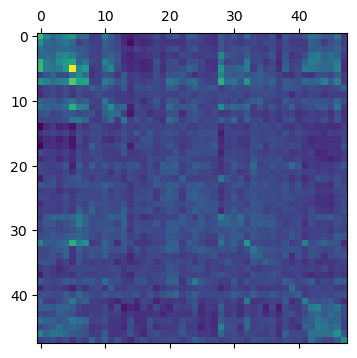

In [ ]:

matshow(out["results"]["split"].vld[0].Cest)